# Optimizing a segmentation workflow

Choosing good parameters for an image processing workflow (e.g. a blur sigma and a
threshold) is often done by trial and error. This notebook shows a more systematic way:
given a sparse manual annotation of an image, we define a
[fitness function](https://en.wikipedia.org/wiki/Fitness_function) that scores how well a
workflow's output matches the annotation, and let
[`scipy.optimize.minimize`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html)
search for the parameters that maximize that score.

See also:
* [Jaccard index](https://en.wikipedia.org/wiki/Jaccard_index)


In [2]:
import numpy as np
from skimage.io import imread
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import pyclesperanto as cle

cle.select_device()


(OpenCL) Apple M5 Max (OpenCL 1.2)
	Vendor:                      Apple
	Driver Version:              1.2 1.0
	Device Type:                 GPU
	Compute Units:               40
	Global Memory Size:          53084 MB
	Local Memory Size:           0 MB
	Maximum Buffer Size:         9953 MB
	Max Clock Frequency:         1000 MHz
	Image Support:               Yes

## Load the example image and annotation

We load the `blobs.png` sample image, along with a manual annotation of it. The annotation
does not need to cover every object in the image (sparse annotation): pixel value `0` means
"unknown", `1` means "background", and `2` means "foreground".


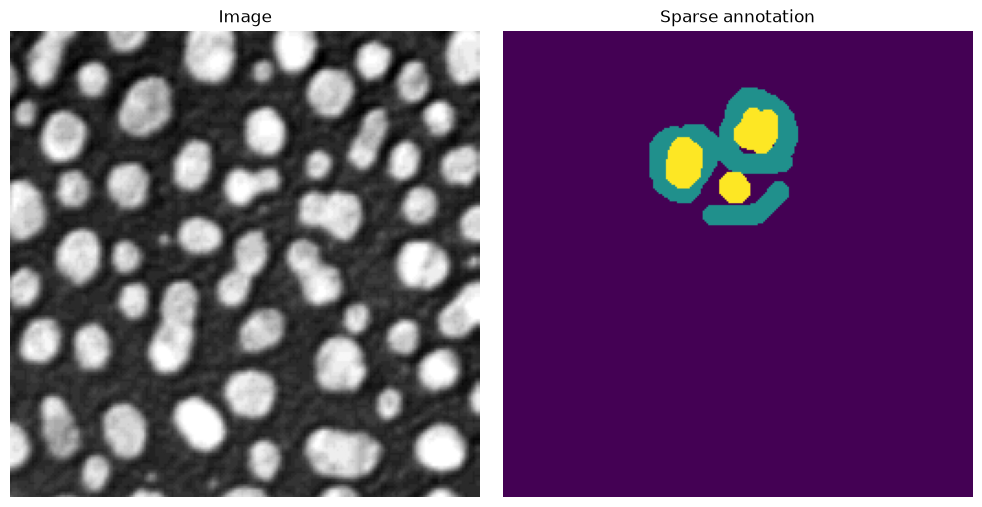

In [3]:
blobs = cle.push(imread('https://samples.fiji.sc/blobs.png').squeeze().astype(float))
annotation = cle.push(imread('https://github.com/clEsperanto/pyclesperanto_prototype/raw/master/data/blobs_annotated.tif'))

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(blobs, cmap='gray')
axs[0].set_title('Image')
axs[1].imshow(annotation, cmap='viridis')
axs[1].set_title('Sparse annotation')
for ax in axs:
    ax.axis('off')
plt.tight_layout()
plt.show()


## Define the workflow

The workflow we want to optimize is a simple Gaussian blur followed by a constant
threshold. It takes an image and two parameters, `sigma` and `threshold`, and returns a
binary image.


array([[0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(254, 256), dtype=uint8, mtype=buffer)
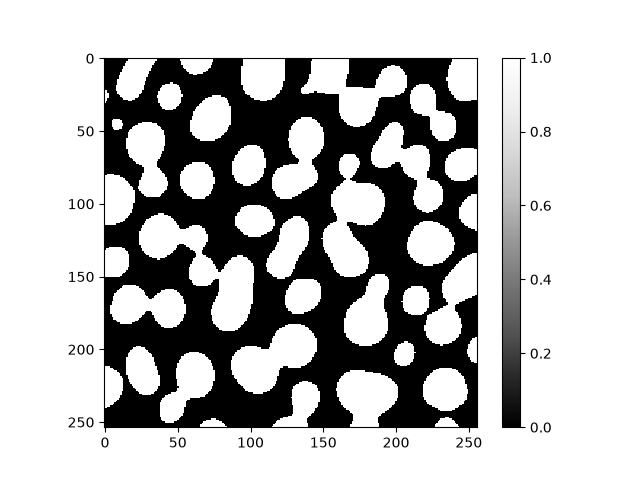
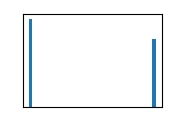

In [4]:
def my_workflow(image, sigma, threshold):
    blurred = cle.gaussian_blur(image, sigma_x=sigma, sigma_y=sigma)
    binary = cle.greater_constant(blurred, scalar=threshold)
    return binary

# test the workflow with arbitrary parameters
test = my_workflow(blobs, 5, 100)
test


## Define a fitness function

We can tell by eye that the segmentation above is not great, but to search for better
parameters automatically we need a way to score a segmentation result against the
annotation. We use the [Jaccard index](https://en.wikipedia.org/wiki/Jaccard_index),
computed from true/false positives/negatives, ignoring the "unknown" annotation pixels.


In [5]:
def fitness(test, reference):
    """
    Determine how correct a given test segmentation is, using the Jaccard index as metric.
    Assumption: test is a binary image (0=False, 1=True) and reference is an image with
    0=unknown, 1=False, 2=True.
    """
    negative_reference = reference == 1
    positive_reference = reference == 2
    negative_test = test == 0
    positive_test = test == 1

    tp = cle.binary_and(positive_reference, positive_test).sum()
    tn = cle.binary_and(negative_reference, negative_test).sum()
    fp = cle.binary_and(negative_reference, positive_test).sum()
    fn = cle.binary_and(positive_reference, negative_test).sum()

    return tp / (tp + fn + fp)

print(f"Fitness of the first test: {fitness(test, annotation):.3f}")


Fitness of the first test: 0.743


## Manual parameter search

With a workflow and a fitness function in hand, we can start exploring the parameter
space "by hand", for example by scanning a range of threshold values.


In [6]:
for t in range(70, 180, 10):
    test = my_workflow(blobs, 5, t)
    print(f"threshold={t}: fitness={fitness(test, annotation):.3f}")


threshold=70: fitness=0.490
threshold=80: fitness=0.584
threshold=90: fitness=0.670
threshold=100: fitness=0.743
threshold=110: fitness=0.818
threshold=120: fitness=0.838
threshold=130: fitness=0.791
threshold=140: fitness=0.702
threshold=150: fitness=0.606
threshold=160: fitness=0.498
threshold=170: fitness=0.397


This is tedious even with a single free parameter, and our workflow actually has two
(`sigma` and `threshold`). Instead of searching by hand, we can let
`scipy.optimize.minimize` search the parameter space for us.


## Automatic optimization

`scipy.optimize.minimize` looks for the parameters that *minimize* a given function, so we
minimize the negative fitness. We start the search from an arbitrary point in parameter
space (`sigma=5`, `threshold=100`).


In [7]:
def objective(x):
    test = my_workflow(blobs, x[0], x[1])
    # minimize() looks for a minimum, so we negate the fitness
    return -fitness(test, annotation)

x0 = np.array([5, 100])

result = minimize(objective, x0, method='nelder-mead', options={'xatol': 1e-3, 'disp': True})

best_sigma, best_threshold = result['x']
print(f"\nBest parameters: sigma={best_sigma:.3f}, threshold={best_threshold:.3f}")
print(f"Best fitness: {-result['fun']:.3f}")


Optimization terminated successfully.
         Current function value: -0.857613
         Iterations: 22
         Function evaluations: 65

Best parameters: sigma=3.895, threshold=121.941
Best fitness: 0.858


## Compare the result

Finally, we run the workflow with the optimized parameters and compare it to our initial,
manually-chosen result.


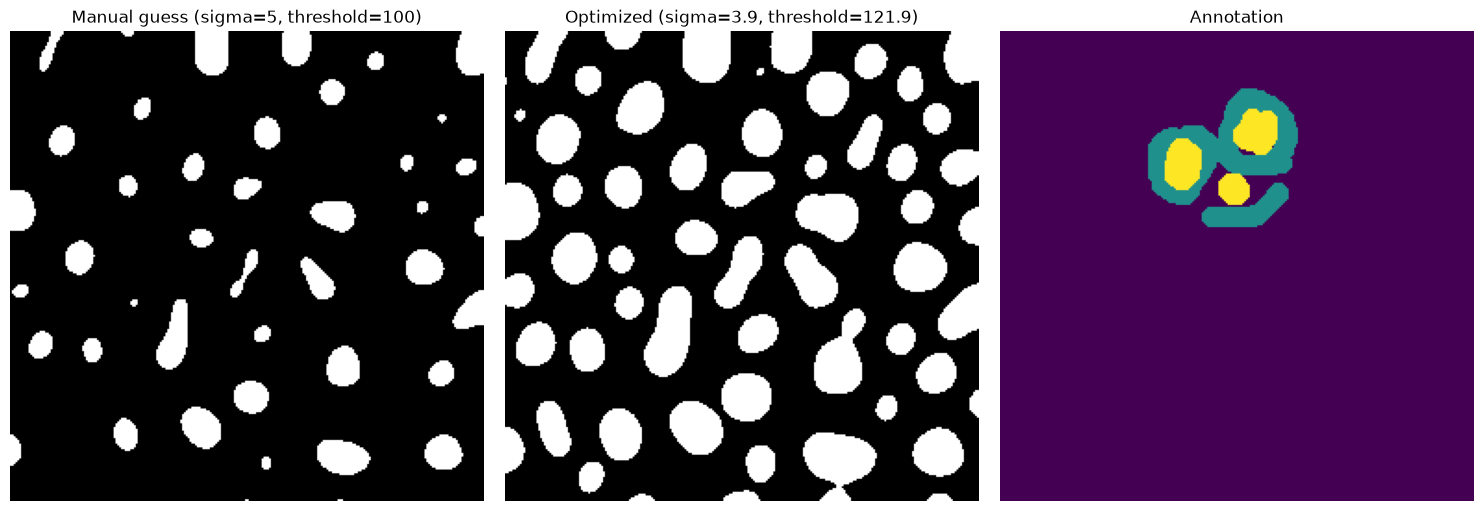

In [8]:
best_binary = my_workflow(blobs, best_sigma, best_threshold)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(test, cmap='gray')
axs[0].set_title('Manual guess (sigma=5, threshold=100)')
axs[1].imshow(best_binary, cmap='gray')
axs[1].set_title(f'Optimized (sigma={best_sigma:.1f}, threshold={best_threshold:.1f})')
axs[2].imshow(annotation, cmap='viridis')
axs[2].set_title('Annotation')
for ax in axs:
    ax.axis('off')
plt.tight_layout()
plt.show()


> Note:
> This strategy is not specific to pyclesperanto: the same approach works with workflows
> built from other libraries, e.g. scikit-image. Running the workflow on the GPU with
> pyclesperanto simply makes each evaluation - and therefore the whole search - faster.
